# Customer Segmentation — EDA & Pre-Processing

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score

## 1. Load Data

In [2]:
costumer = pd.read_csv("customer_info.csv")
costumer

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


In [3]:
# FIX: load basket HERE, before it is used in the merge step below
costumer_basket = pd.read_csv("customer_basket.csv")
costumer_basket

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


## 2. Initial Inspection — customer_info

In [4]:
costumer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

In [5]:
costumer.isnull().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [6]:
costumer.duplicated().sum()

np.int64(0)

## 3. Initial Inspection — customer_basket

In [7]:
costumer_basket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   invoice_id     100000 non-null  int64 
 1   list_of_goods  100000 non-null  object
 2   customer_id    100000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.3+ MB


In [8]:
costumer_basket.duplicated().sum()
# costumer_basket is okay — no nulls, no duplicates

np.int64(0)

## 4. Feature Engineering

In [9]:
current_year = datetime.now().year

# Convert birthdate to age
costumer['age'] = current_year - pd.to_datetime(costumer['customer_birthdate'], format='mixed').dt.year

# Convert first transaction year to seniority
costumer['years_as_customer'] = current_year - costumer['year_first_transaction']

# Binary flag for loyalty card
costumer['has_loyalty_card'] = costumer['loyalty_card_number'].notnull().astype(int)

# Encode gender — astype(str) guards against any unexpected NaN
le = LabelEncoder()
costumer['customer_gender'] = le.fit_transform(costumer['customer_gender'].astype(str))

## 5. Outlier Visualisation & Capping

Capping is applied only to **spend / behavioural** numeric columns —  
identifiers (`customer_id`), coordinates (`latitude`, `longitude`) and the  
binary/encoded columns are excluded.

In [10]:
# Columns that should NOT be capped
exclude_from_capping = [
    'customer_id', 'customer_gender', 'latitude', 'longitude',
    'loyalty_card_number', 'has_loyalty_card', 'year_first_transaction'
]

cap_cols = [
    col for col in costumer.select_dtypes(include='number').columns
    if col not in exclude_from_capping
]

# Determine number of rows needed for subplots (3 columns per row)
n_rows = math.ceil(len(cap_cols) / 3)

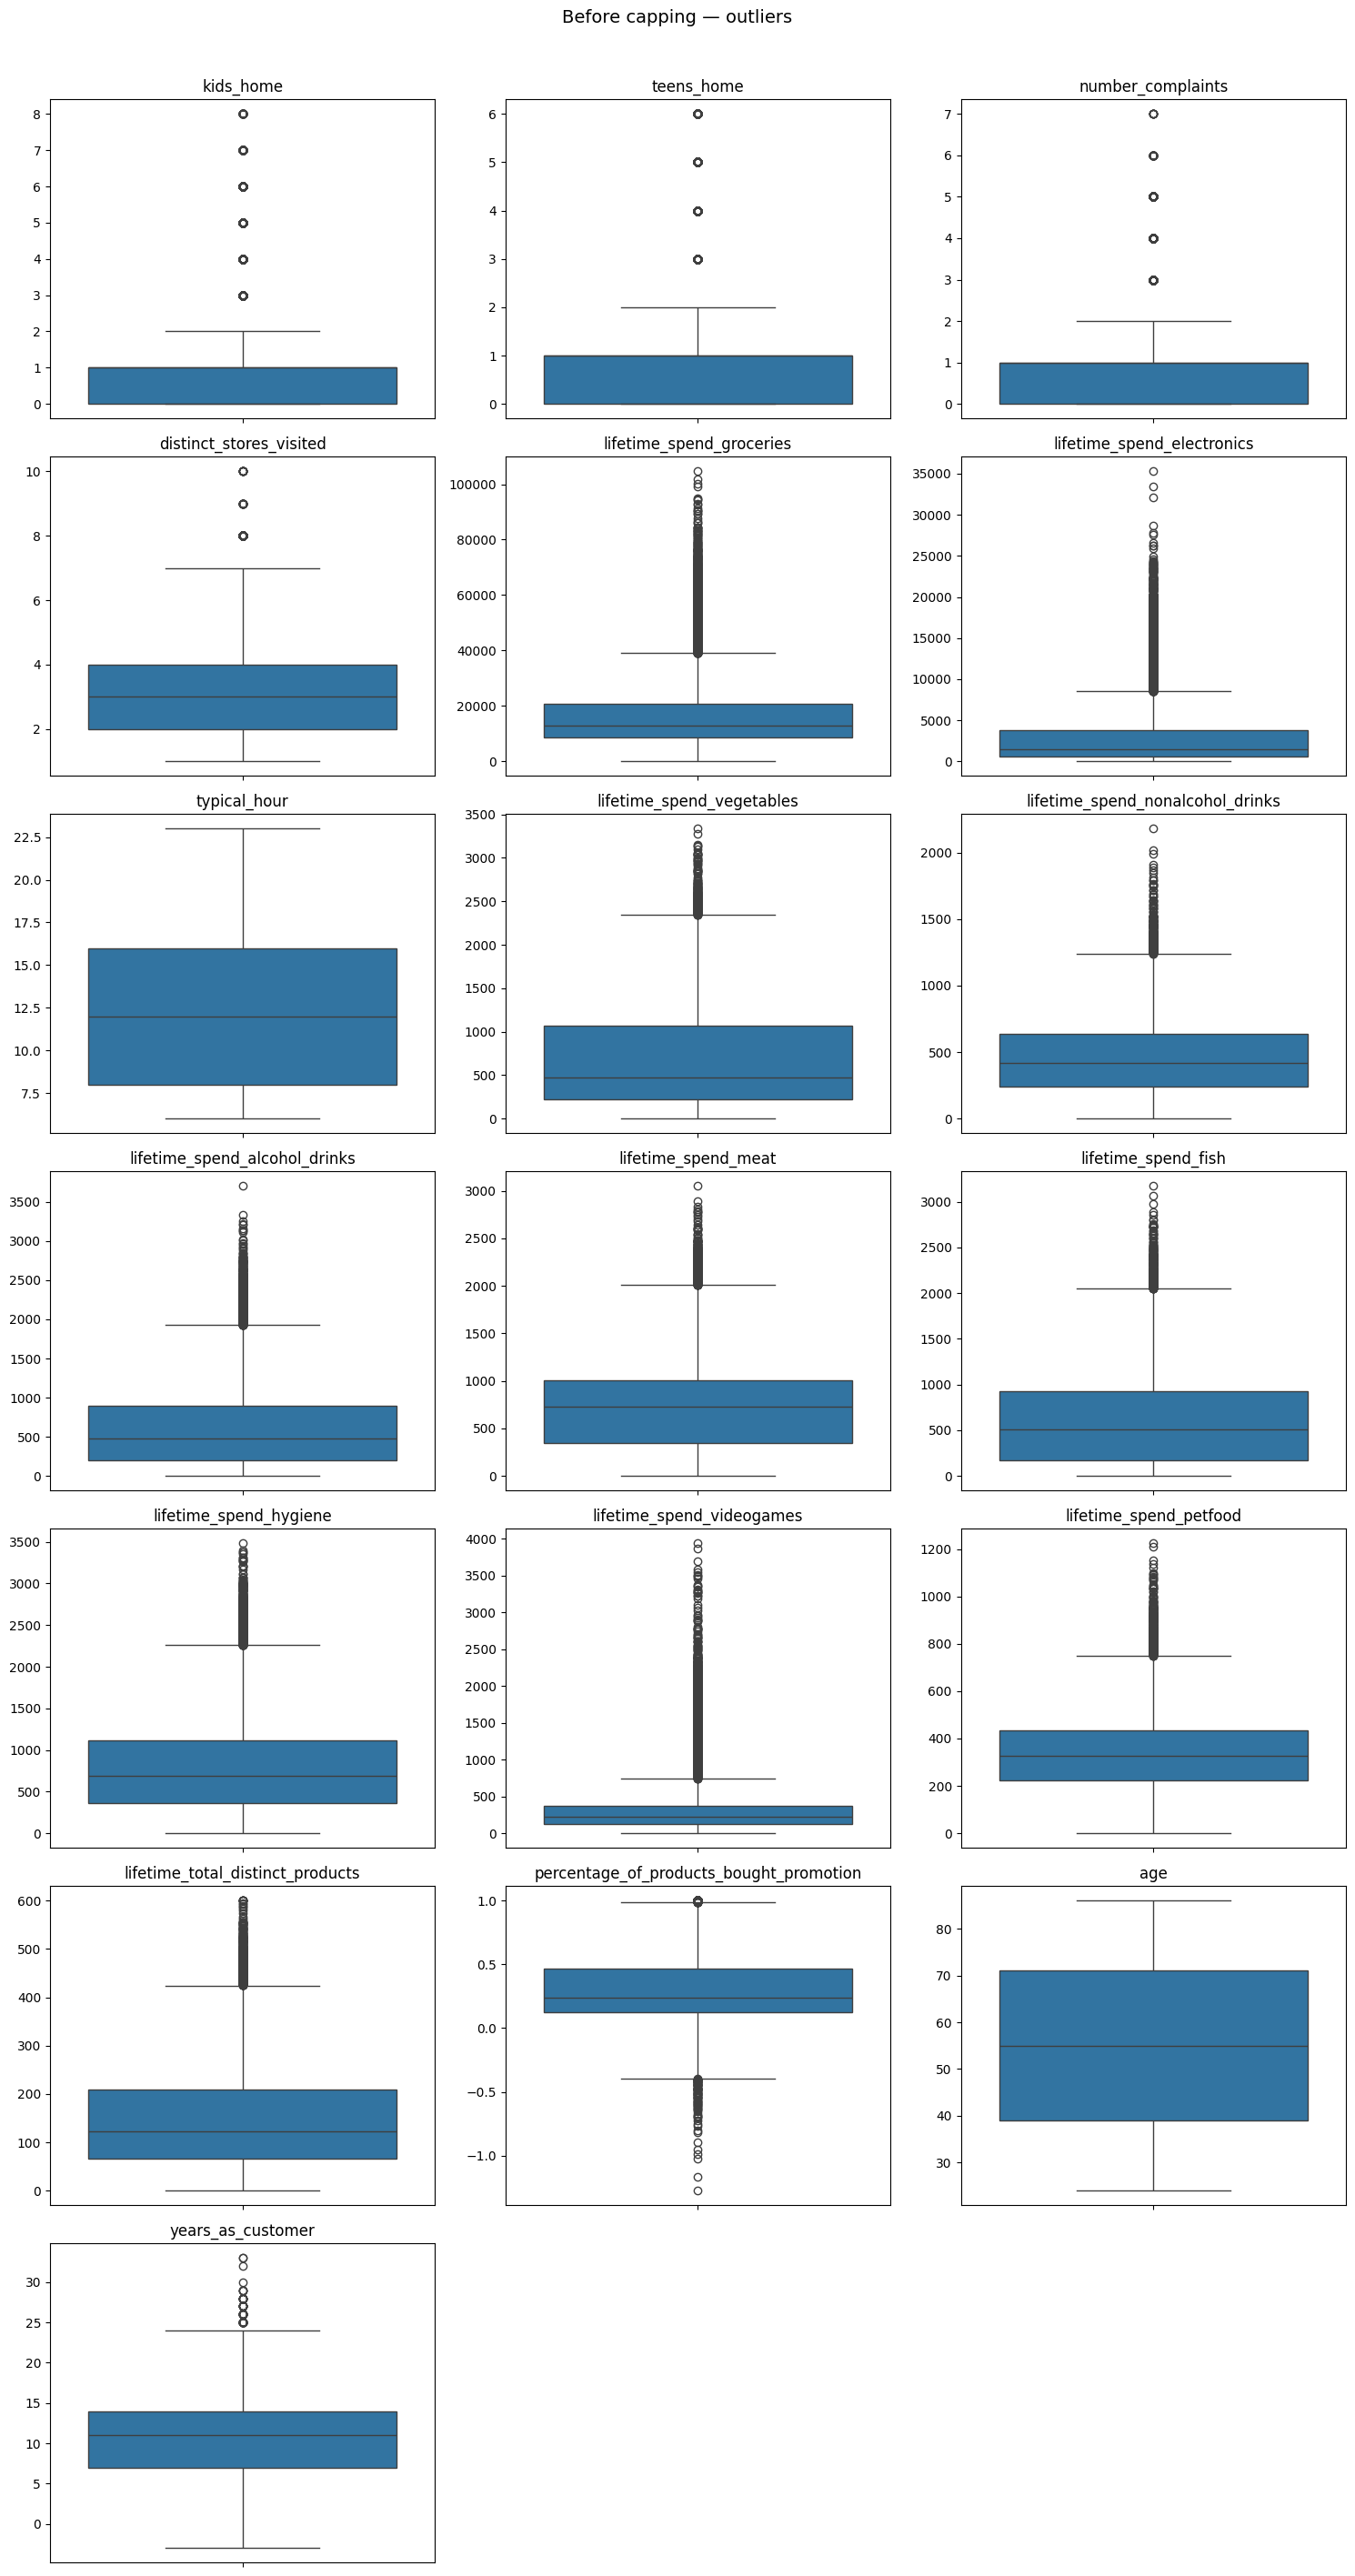

In [11]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cap_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# FIX: use fig.suptitle instead of plt.title for multi-subplot figures
fig.suptitle("Before capping — outliers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
for col in cap_cols:
    Q1 = costumer[col].quantile(0.25)
    Q3 = costumer[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    costumer[col] = np.clip(costumer[col], lower, upper)

print("Outlier capping applied to:", cap_cols)

Outlier capping applied to: ['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'age', 'years_as_customer']


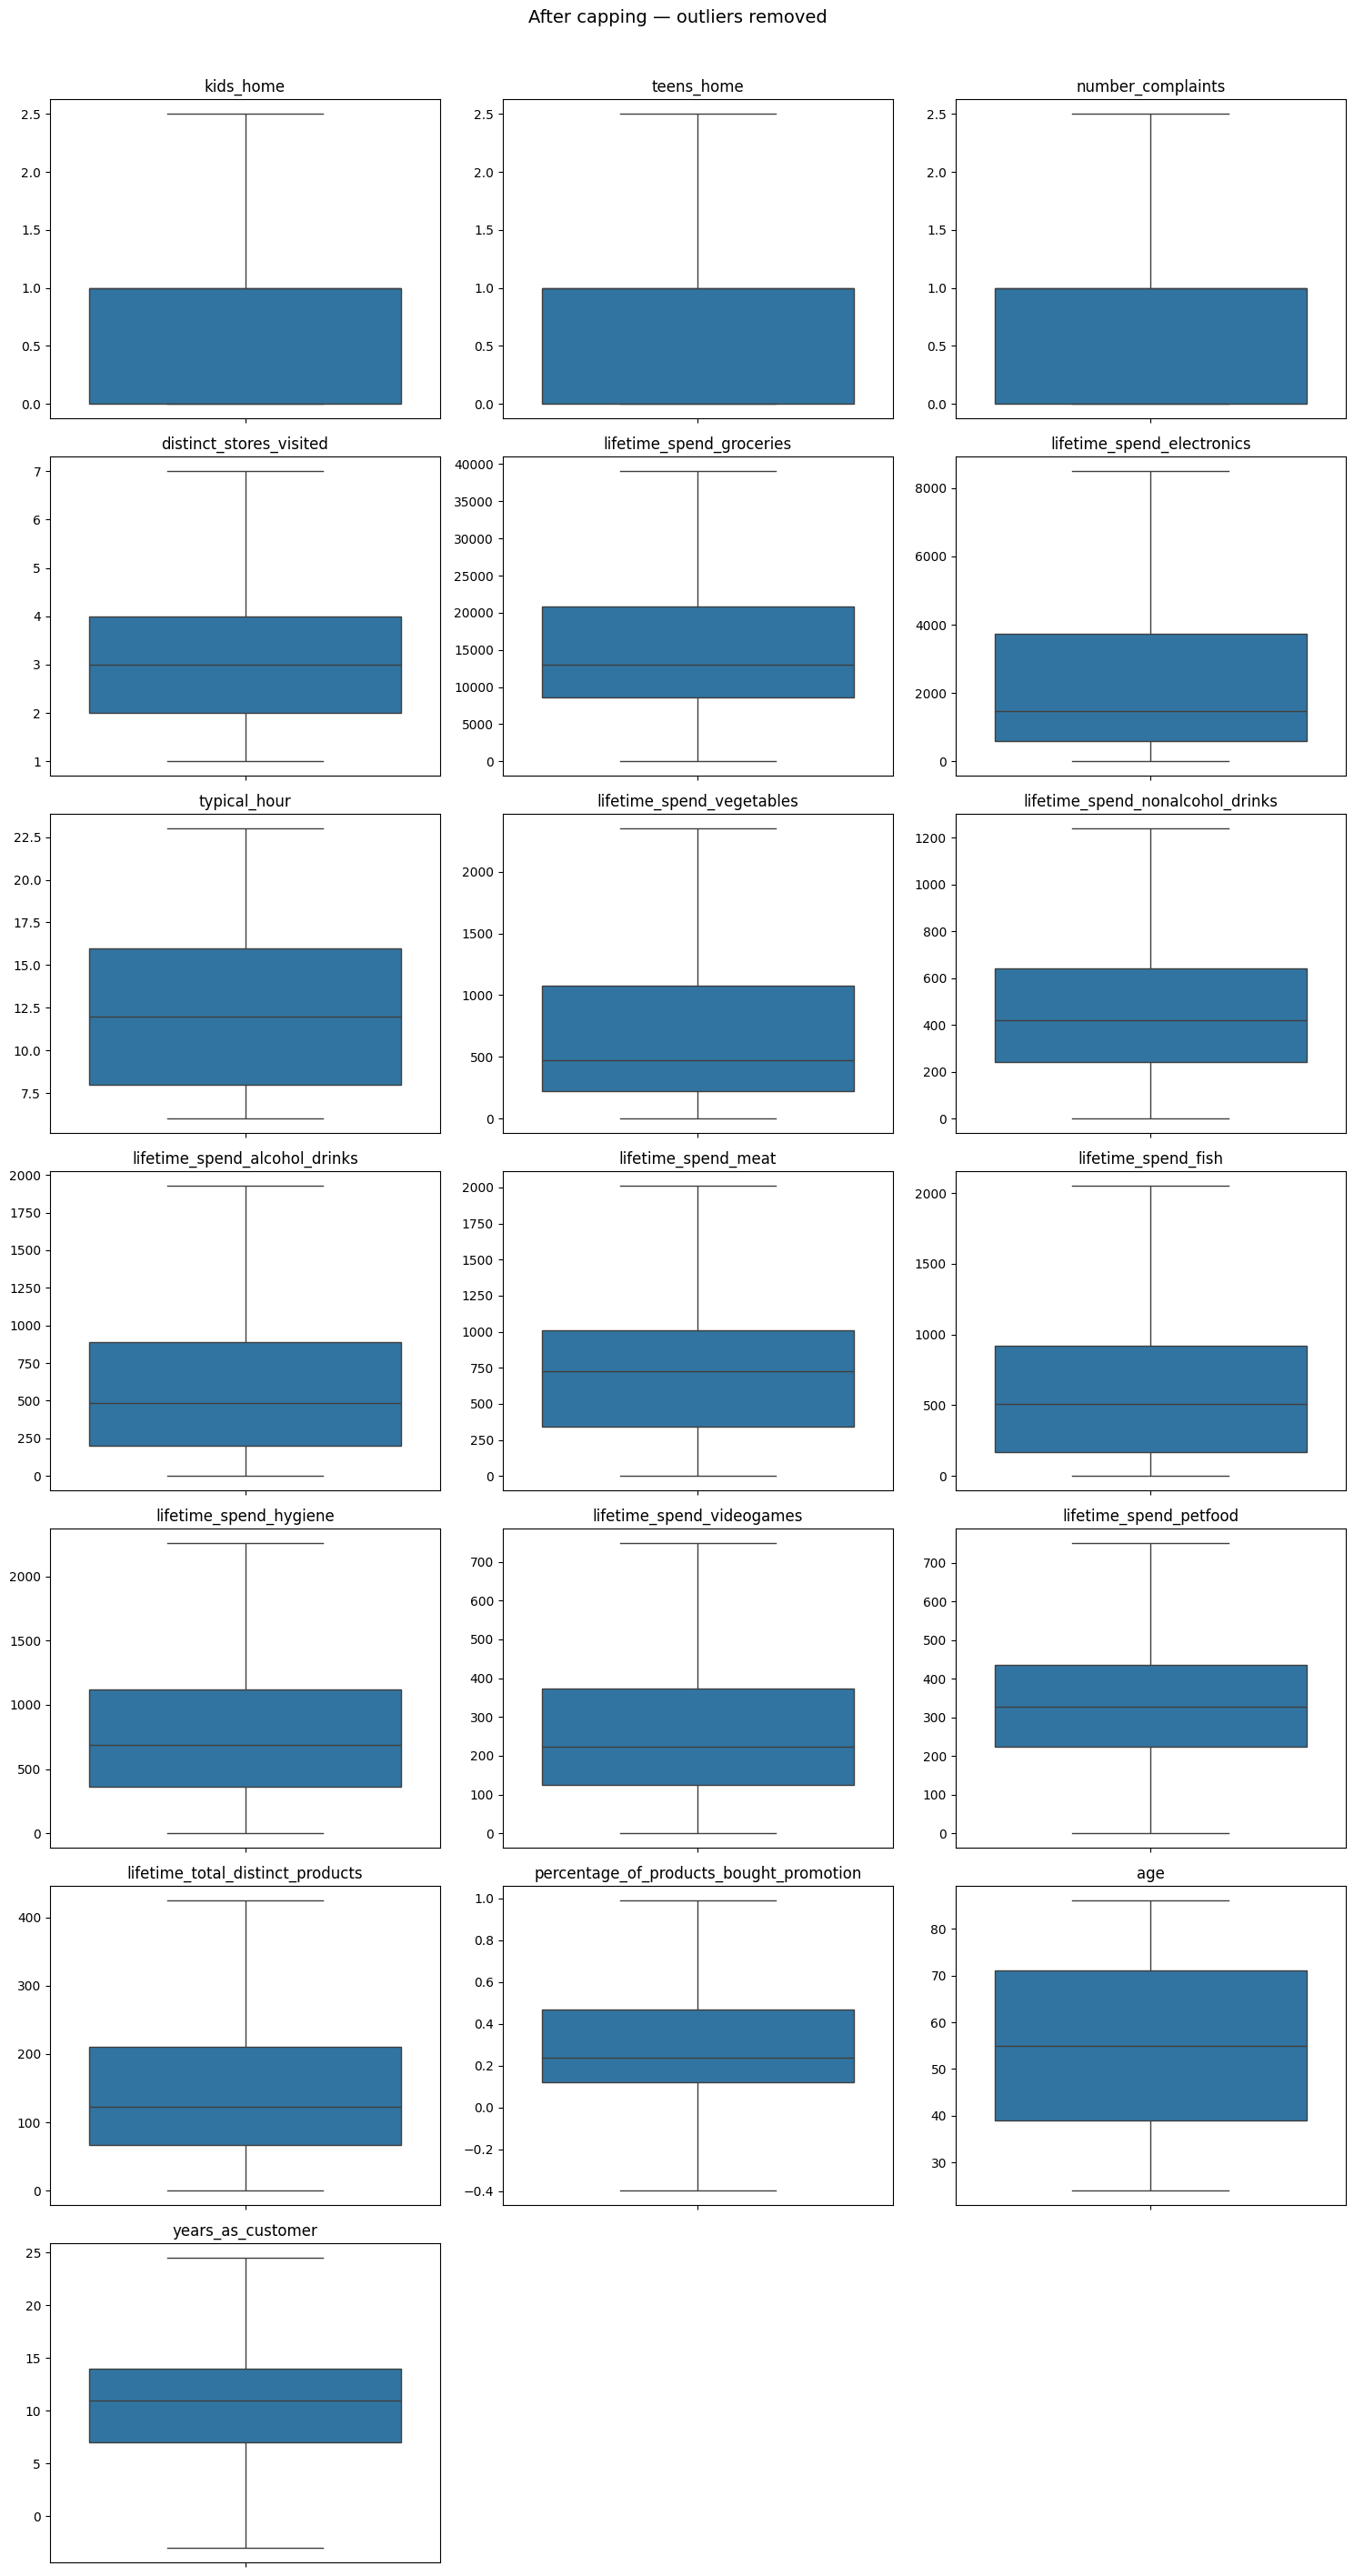

In [13]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cap_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# FIX: use fig.suptitle instead of plt.title
fig.suptitle("After capping — outliers removed", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Missing Values — MICE Imputation

In [14]:
missing_pct = costumer.isnull().sum() * 100 / len(costumer)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

loyalty_card_number                        39.669472
lifetime_spend_fish                         2.999576
lifetime_spend_petfood                      2.000726
number_complaints                           2.000726
lifetime_spend_vegetables                   2.000726
lifetime_spend_meat                         2.000726
lifetime_spend_videogames                   2.000726
typical_hour                                2.000726
lifetime_spend_electronics                  2.000726
lifetime_spend_alcohol_drinks               0.998850
kids_home                                   0.998850
teens_home                                  0.998850
distinct_stores_visited                     0.998850
percentage_of_products_bought_promotion     0.998850
lifetime_spend_hygiene                      0.998850
customer_birthdate                          0.499425
age                                         0.499425
dtype: float64


In [15]:
# Columns excluded from MICE: non-numeric / identifiers / already-derived flags
cols_to_drop_for_mice = [
    'customer_id',
    'customer_name',
    'customer_birthdate',   # already replaced by 'age'
    'loyalty_card_number',  # already replaced by 'has_loyalty_card'
    'latitude',
    'longitude',
]

# FIX: errors='ignore' avoids KeyError if any column was already dropped
cols_mice = costumer.drop(columns=cols_to_drop_for_mice, errors='ignore').select_dtypes(include='number').columns

imputer = IterativeImputer(max_iter=10, random_state=42)
costumer[cols_mice] = imputer.fit_transform(costumer[cols_mice])

# Drop columns no longer needed
costumer.drop(columns=['customer_birthdate', 'loyalty_card_number'], inplace=True, errors='ignore')

print("Missing values after MICE:")
print(costumer.isnull().sum())

Missing values after MICE:
customer_id                                0
customer_name                              0
customer_gender                            0
kids_home                                  0
teens_home                                 0
number_complaints                          0
distinct_stores_visited                    0
lifetime_spend_groceries                   0
lifetime_spend_electronics                 0
typical_hour                               0
lifetime_spend_vegetables                  0
lifetime_spend_nonalcohol_drinks           0
lifetime_spend_alcohol_drinks              0
lifetime_spend_meat                        0
lifetime_spend_fish                        0
lifetime_spend_hygiene                     0
lifetime_spend_videogames                  0
lifetime_spend_petfood                     0
lifetime_total_distinct_products           0
percentage_of_products_bought_promotion    0
year_first_transaction                     0
latitude                    

## 7. Merge, Scale & Export

`costumer_basket` is aggregated to **total_transactions per customer** and  
merged with `costumer` before scaling.

In [16]:
# Aggregate basket: number of transactions per customer
aggregated_basket = (
    costumer_basket
    .groupby('customer_id')
    .agg(total_transactions=('invoice_id', 'count'))
    .reset_index()
)

# Merge — inner join keeps only customers present in both datasets
combined_df = pd.merge(costumer, aggregated_basket, on='customer_id', how='inner')

# Drop non-predictive columns
cols_to_drop = ['customer_name', 'latitude', 'longitude']
featured_df = combined_df.drop(columns=[c for c in cols_to_drop if c in combined_df.columns])
featured_df.to_csv("costumer_featured.csv", index=False)
final_df = featured_df.drop(columns=['customer_id']) 

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_df)
costumer_preprocessed = pd.DataFrame(scaled_data, columns=final_df.columns)

print(f"Shape after merge & scaling: {costumer_preprocessed.shape}")
costumer_preprocessed.head()

Shape after merge & scaling: (28127, 23)


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,age,years_as_customer,has_loyalty_card,total_transactions
0,-0.998188,0.010659,0.230412,0.153070,-0.102547,-0.396734,0.864309,0.331260,-0.559565,-0.530987,...,-0.460656,-0.120515,0.312273,0.392739,1.139064,0.934048,0.043827,-0.936058,0.808068,-0.560718
1,-0.998188,0.010659,-1.137792,-1.171096,-0.709936,-0.198825,-0.615126,-0.344678,1.949848,0.247045,...,1.786454,0.239733,2.134450,-0.177787,-0.593887,-0.455940,-0.233750,0.458508,0.808068,-0.560718
2,1.001815,-1.281830,-1.137792,-0.372156,-0.709936,-0.328580,-1.011978,-0.341439,-0.280912,-1.353479,...,-0.536800,-0.845689,-0.738234,-0.651615,-0.884438,-2.044499,-0.011689,2.052296,-1.237520,-0.921238
3,1.001815,-1.281830,-1.137792,1.477235,-1.317324,-0.824008,-0.556608,1.117804,-1.002043,1.076947,...,-0.574027,2.178989,-0.984650,-0.545245,-0.220757,1.132618,-0.622357,-1.135281,0.808068,-0.921238
4,-0.998188,0.010659,0.230412,0.153070,1.719618,0.087099,-0.535591,-1.383756,1.484405,-0.223479,...,-0.526648,-0.265549,-0.216509,-0.622605,-0.591169,-0.853080,0.154857,0.856955,0.808068,-0.560718


In [17]:
costumer_preprocessed.to_csv("costumer_preprocessed_combined.csv", index=False)
print("Saved : costumer_preprocessed_combined.csv")

Saved : costumer_preprocessed_combined.csv
